In [ ]:
# Luxury Resale Price Analysis
### Vestiaire Collective Marketplace Data

## Project Objective

This analysis explores the factors associated with luxury resale listing prices using a dataset of 10,409 Vestiaire Collective listings.

The analysis focuses on three questions:

1. Which product characteristics are associated with higher luxury resale listing prices?
2. How do brand, category, and condition relate to pricing?
3. Can listing characteristics be used to predict resale listing prices?

The project combines SQL-based marketplace analysis with Python exploratory data analysis, visualization, and machine learning.


In [1]:
import pandas as pd

# Load the Vestiaire Collective dataset
df = pd.read_csv("vestiaire_raw.csv")

# Display basic dataset information
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10409, 15)


,id,url,num_likes,price,we_love_tag,online_date,gender,category,sub_category,designer,condition,material,color,size,location
0,19126896,https://fr.vestiairecollective.com//women-shoe...,7,180.00,True,09/11/2021,women,shoes,ankle boots,acne studios,very good condition,leather,black,"['39', 'eu']",italy
1,19181389,https://fr.vestiairecollective.com//women-clot...,1,40.55,True,12/11/2021,women,clothing,jeans,acne studios,good condition,denim - jeans,navy,"['30', 'us']",poland
2,19182029,https://fr.vestiairecollective.com//men-clothi...,6,332.50,True,12/11/2021,men,clothing,coats,acne studios,good condition,wool,black,"['l', 'international']",denmark
3,19132670,https://fr.vestiairecollective.com//men-clothi...,3,45.00,False,09/11/2021,men,clothing,jeans,acne studios,"never worn, with tag",cotton,grey,"['28', 'us']",germany
4,19118182,https://fr.vestiairecollective.com//women-clot...,9,105.00,False,09/11/2021,women,clothing,dresses,acne studios,very good condition,linen,black,"['s', 'international']",germany


In [2]:
# Inspect column names, data types, and missing values

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['id', 'url', 'num_likes', 'price', 'we_love_tag', 'online_date', 'gender', 'category', 'sub_category', 'designer', 'condition', 'material', 'color', 'size', 'location']

Data types:
id                int64
url                 str
num_likes         int64
price           float64
we_love_tag        bool
online_date         str
gender              str
category            str
sub_category        str
designer            str
condition           str
material            str
color               str
size                str
location            str
dtype: object

Missing values:
id              0
url             0
num_likes       0
price           0
we_love_tag     0
online_date     0
gender          0
category        0
sub_category    0
designer        0
condition       0
material        0
color           0
size            0
location        0
dtype: int64


In [3]:
# Convert online_date from text to a datetime variable
df["online_date"] = pd.to_datetime(
    df["online_date"],
    format="%d/%m/%Y"
)

# Check for duplicate listing IDs
duplicate_ids = df["id"].duplicated().sum()

print("Duplicate listing IDs:", duplicate_ids)
print("Online date type:", df["online_date"].dtype)
print("Earliest listing:", df["online_date"].min())
print("Latest listing:", df["online_date"].max())

Duplicate listing IDs: 0
Online date type: datetime64[us]
Earliest listing: 2020-11-21 00:00:00
Latest listing: 2021-11-16 00:00:00


In [4]:
# Summary statistics for listing price
print(df["price"].describe())

print("\nMedian price:", round(df["price"].median(), 2))
print("Listings over $5,000:", (df["price"] > 5000).sum())
print("Listings over $10,000:", (df["price"] > 10000).sum())

count    10409.000000
mean       410.616666
std        678.736446
min         16.000000
25%        130.000000
50%        250.000000
75%        450.000000
max      25000.000000
Name: price, dtype: float64

Median price: 250.0
Listings over $5,000: 25
Listings over $10,000: 4


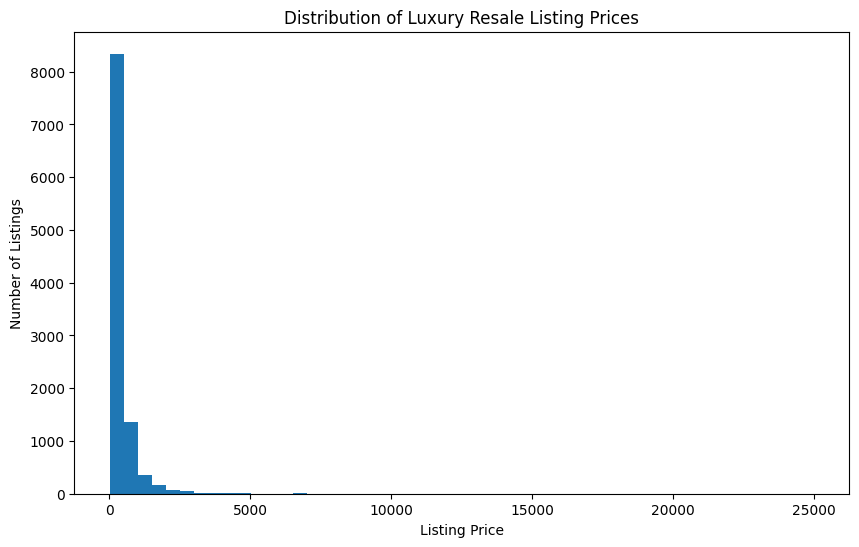

In [5]:
import matplotlib.pyplot as plt

# Visualize the distribution of listing prices
plt.figure(figsize=(10, 6))
plt.hist(df["price"], bins=50)

plt.title("Distribution of Luxury Resale Listing Prices")
plt.xlabel("Listing Price")
plt.ylabel("Number of Listings")

plt.show()

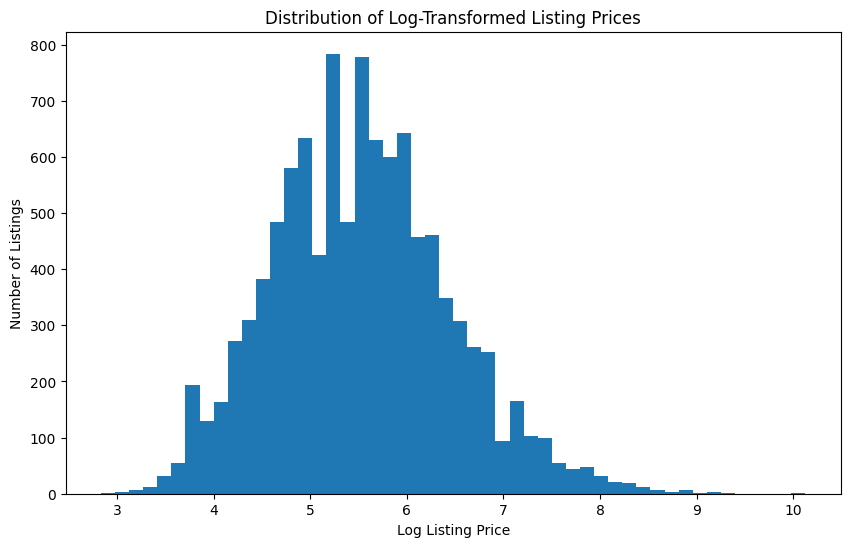

In [6]:
import numpy as np

# Create a log-transformed version of price
df["log_price"] = np.log1p(df["price"])

# Visualize the transformed price distribution
plt.figure(figsize=(10, 6))
plt.hist(df["log_price"], bins=50)

plt.title("Distribution of Log-Transformed Listing Prices")
plt.xlabel("Log Listing Price")
plt.ylabel("Number of Listings")

plt.show()

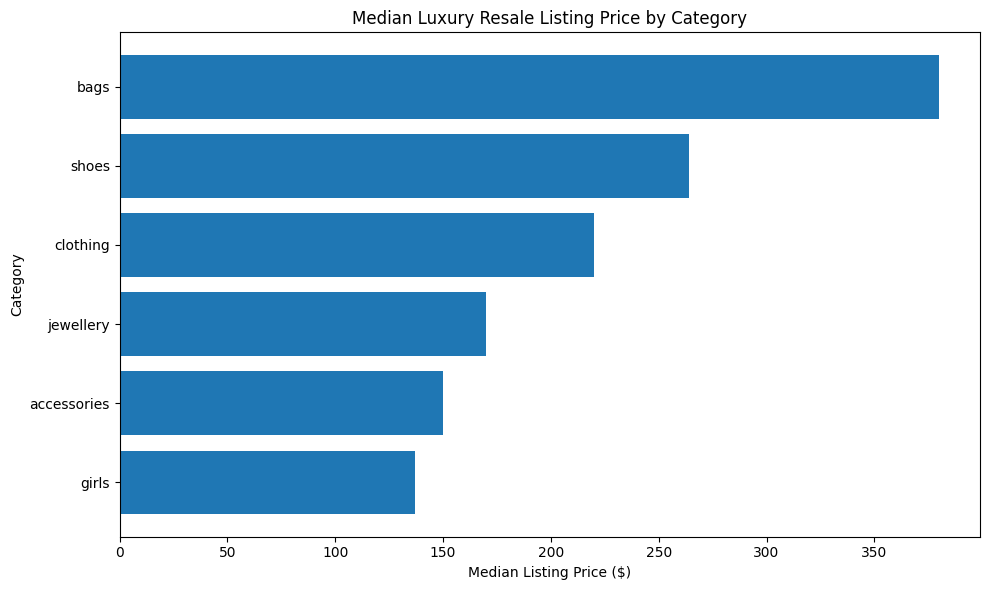

In [9]:
# Calculate category-level listing counts and median prices
category_summary = (
    df.groupby("category")
      .agg(
          listing_count=("price", "size"),
          median_price=("price", "median")
      )
)

# Keep categories with at least 50 listings
category_summary = (
    category_summary[category_summary["listing_count"] >= 50]
    .sort_values("median_price", ascending=True)
)

# Visualize median listing price by category
plt.figure(figsize=(10, 6))
plt.barh(
    category_summary.index,
    category_summary["median_price"]
)

plt.title("Median Luxury Resale Listing Price by Category")
plt.xlabel("Median Listing Price ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

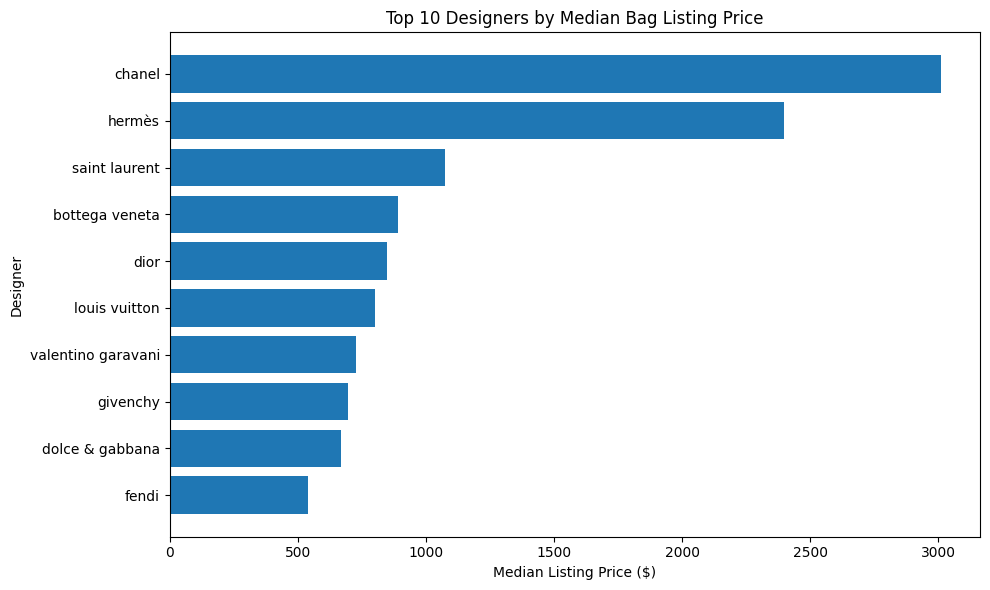

In [10]:
# Filter to bag listings
bags = df[df["category"] == "bags"]

# Calculate bag count and median price by designer
bag_designer_summary = (
    bags.groupby("designer")
        .agg(
            bag_count=("price", "size"),
            median_price=("price", "median")
        )
)

# Keep designers with at least 20 bag listings
bag_designer_summary = (
    bag_designer_summary[bag_designer_summary["bag_count"] >= 20]
    .sort_values("median_price", ascending=False)
)

# Select the top 10 designers by median bag price
top_bag_designers = bag_designer_summary.head(10).sort_values(
    "median_price",
    ascending=True
)

# Visualize
plt.figure(figsize=(10, 6))

plt.barh(
    top_bag_designers.index,
    top_bag_designers["median_price"]
)

plt.title("Top 10 Designers by Median Bag Listing Price")
plt.xlabel("Median Listing Price ($)")
plt.ylabel("Designer")

plt.tight_layout()
plt.show()

### Key Finding: Brand Premium in Luxury Handbags

Among designers with at least 20 bag listings, Chanel had the highest median listing price at approximately **\$3,013**, followed by Hermès at **\$2,400**. The next-highest brand, Saint Laurent, had a median price of approximately **\$1,076**.

The substantial gap suggests that designer brand is strongly associated with listing price within the handbag category. Comparing products within the same category also helps reduce differences caused by product mix.

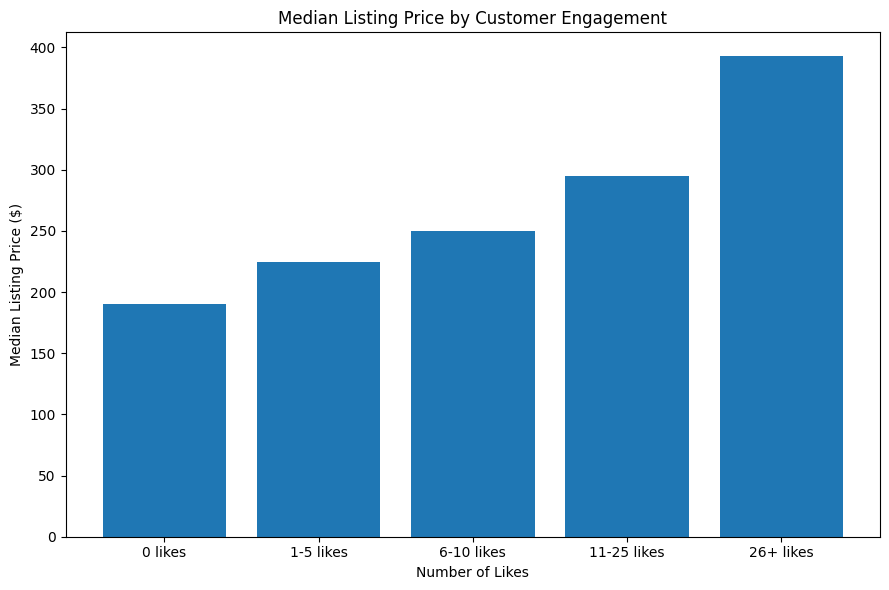

In [11]:
# Create engagement groups based on number of likes
df["engagement_level"] = pd.cut(
    df["num_likes"],
    bins=[-1, 0, 5, 10, 25, float("inf")],
    labels=["0 likes", "1-5 likes", "6-10 likes", "11-25 likes", "26+ likes"]
)

# Calculate median price by engagement level
engagement_summary = (
    df.groupby("engagement_level", observed=True)["price"]
      .median()
)

# Visualize
plt.figure(figsize=(9, 6))

plt.bar(
    engagement_summary.index,
    engagement_summary.values
)

plt.title("Median Listing Price by Customer Engagement")
plt.xlabel("Number of Likes")
plt.ylabel("Median Listing Price ($)")

plt.tight_layout()
plt.show()

Customer engagement increased consistently across higher-priced listing groups. Listings with **26+ likes** had a median listing price of approximately **\$393**, compared with **\$190** for listings with no likes.

This indicates a positive association between listing price and customer engagement. However, the relationship should not be interpreted as causal, since factors such as designer, category, product desirability, and listing exposure may influence both price and engagement.

## Machine Learning: Predicting Luxury Resale Listing Prices

The goal of this section is to evaluate how well product and listing characteristics can predict luxury resale listing prices.

Because the raw price distribution is strongly right-skewed, the model will predict **log-transformed listing price (`log_price`)**. Model predictions can later be converted back into dollar values for interpretation.

### Candidate Predictors

The model will initially consider:

- Designer
- Category
- Sub-category
- Condition
- Material
- Color
- Gender
- Seller location
- "We Love" designation
- Number of likes

Identifiers such as listing ID and URL will not be used as predictors.

In [13]:
# Select predictor variables
features = [
    "designer",
    "category",
    "sub_category",
    "condition",
    "material",
    "color",
    "gender",
    "location",
    "we_love_tag",
    "num_likes"
]

# X contains the predictors
X = df[features]

# y contains the target we want to predict
y = df["log_price"]

print("Predictor dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

X.head()

Predictor dataset shape: (10409, 10)
Target dataset shape: (10409,)


,designer,category,sub_category,condition,material,color,gender,location,we_love_tag,num_likes
0,acne studios,shoes,ankle boots,very good condition,leather,black,women,italy,True,7
1,acne studios,clothing,jeans,good condition,denim - jeans,navy,women,poland,True,1
2,acne studios,clothing,coats,good condition,wool,black,men,denmark,True,6
3,acne studios,clothing,jeans,"never worn, with tag",cotton,grey,men,germany,False,3
4,acne studios,clothing,dresses,very good condition,linen,black,women,germany,False,9


In [14]:
from sklearn.model_selection import train_test_split

# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training listings:", X_train.shape[0])
print("Testing listings:", X_test.shape[0])

Training listings: 8327
Testing listings: 2082


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical variables that need to be converted to numeric form
categorical_features = [
    "designer",
    "category",
    "sub_category",
    "condition",
    "material",
    "color",
    "gender",
    "location"
]

# Variables that are already numeric or Boolean
numeric_features = [
    "we_love_tag",
    "num_likes"
]

# Create preprocessing instructions
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Create a baseline linear regression pipeline
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model using only the training data
linear_model.fit(X_train, y_train)

print("Baseline linear regression model trained successfully.")

Baseline linear regression model trained successfully.


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict log prices for the unseen test data
y_pred_log = linear_model.predict(X_test)

# Convert predictions and actual values back to dollar prices
y_pred_price = np.expm1(y_pred_log)
y_test_price = np.expm1(y_test)

# Calculate model performance
mae = mean_absolute_error(y_test_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
r2 = r2_score(y_test, y_pred_log)

print("Baseline Linear Regression Results")
print("----------------------------------")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² (log price): {r2:.3f}")

Baseline Linear Regression Results
----------------------------------
MAE: $182.07
RMSE: $468.42
R² (log price): 0.552


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [19]:
# Predict log prices using the Random Forest model
rf_pred_log = random_forest_model.predict(X_test)

# Convert predictions back to dollar prices
rf_pred_price = np.expm1(rf_pred_log)

# Calculate performance metrics
rf_mae = mean_absolute_error(y_test_price, rf_pred_price)
rf_rmse = np.sqrt(mean_squared_error(y_test_price, rf_pred_price))
rf_r2 = r2_score(y_test, rf_pred_log)

print("Random Forest Results")
print("---------------------")
print(f"MAE: ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R² (log price): {rf_r2:.3f}")

Random Forest Results
---------------------
MAE: $174.61
RMSE: $452.37
R² (log price): 0.586


### Model Comparison

The Random Forest model outperformed the baseline linear regression model across all three evaluation metrics. Random Forest reduced mean absolute error from **USD 182.07 to USD 174.61** and RMSE from **USD 468.42 to USD 452.37**, while increasing R² from **0.552 to 0.586**.

These results suggest that nonlinear relationships and interactions among listing characteristics provide additional predictive value beyond a simple linear model. However, substantial unexplained variation remains, indicating that listing price is also influenced by factors not captured in the available dataset.

In [20]:
# Get feature names after preprocessing
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance values from the Random Forest
importances = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)

# Create a table of feature importances
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Show the 15 most important features
top_features = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(15)
)

top_features

,feature,importance
23,categorical__designer_kate spade,0.066318
230,numeric__num_likes,0.060728
64,categorical__sub_category_handbags,0.053744
8,categorical__designer_chanel,0.046370
26,categorical__designer_michael kors,0.040407
11,categorical__designer_coach,0.036570
32,categorical__designer_tory burch,0.033512
111,categorical__condition_never worn,0.027075
55,categorical__sub_category_coats,0.025748
19,categorical__designer_hermès,0.021206


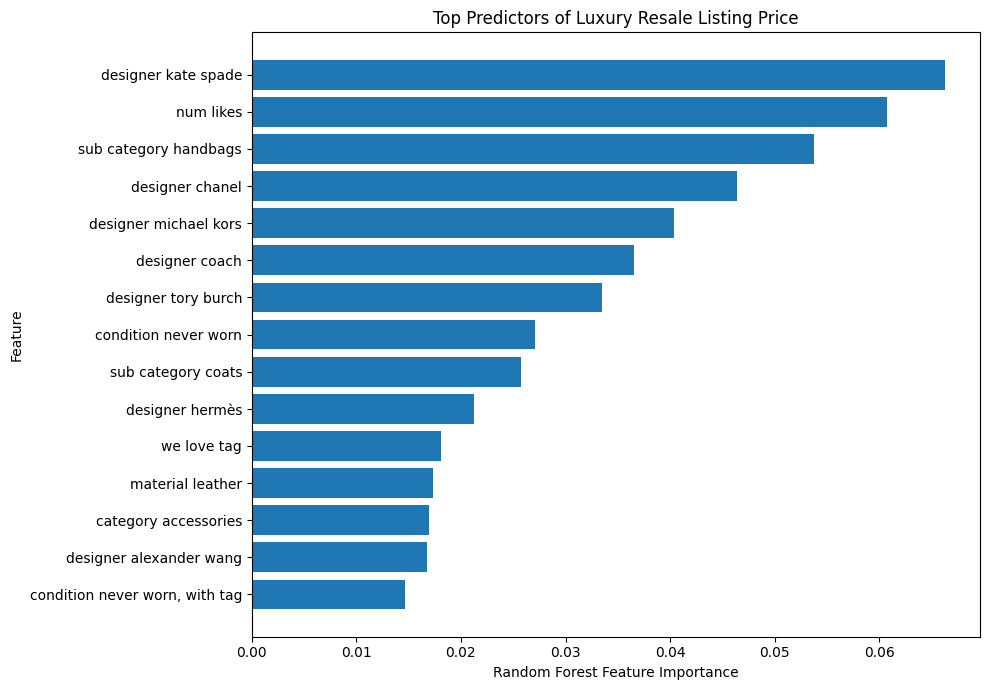

In [21]:
# Clean feature names for visualization
top_features_plot = top_features.copy()

top_features_plot["feature"] = (
    top_features_plot["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numeric__", "", regex=False)
    .str.replace("_", " ")
)

# Sort so the most important feature appears at the top
top_features_plot = top_features_plot.sort_values(
    "importance",
    ascending=True
)

# Create feature importance chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_features_plot["feature"],
    top_features_plot["importance"]
)

plt.title("Top Predictors of Luxury Resale Listing Price")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [22]:
# Group one-hot encoded features back into their original feature categories

def get_feature_group(feature):
    if "designer_" in feature:
        return "Designer"
    elif "sub_category_" in feature:
        return "Sub-category"
    elif "category_" in feature:
        return "Category"
    elif "condition_" in feature:
        return "Condition"
    elif "material_" in feature:
        return "Material"
    elif "color_" in feature:
        return "Color"
    elif "gender_" in feature:
        return "Gender"
    elif "location_" in feature:
        return "Location"
    elif "num_likes" in feature:
        return "Number of Likes"
    elif "we_love_tag" in feature:
        return "We Love Tag"
    else:
        return "Other"

feature_importance["feature_group"] = (
    feature_importance["feature"].apply(get_feature_group)
)

grouped_importance = (
    feature_importance
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

feature_group
Designer           0.390788
Sub-category       0.179864
Material           0.075319
Color              0.073372
Location           0.072494
Condition          0.065147
Number of Likes    0.060728
Category           0.051749
We Love Tag        0.018053
Gender             0.012485
Name: importance, dtype: float64

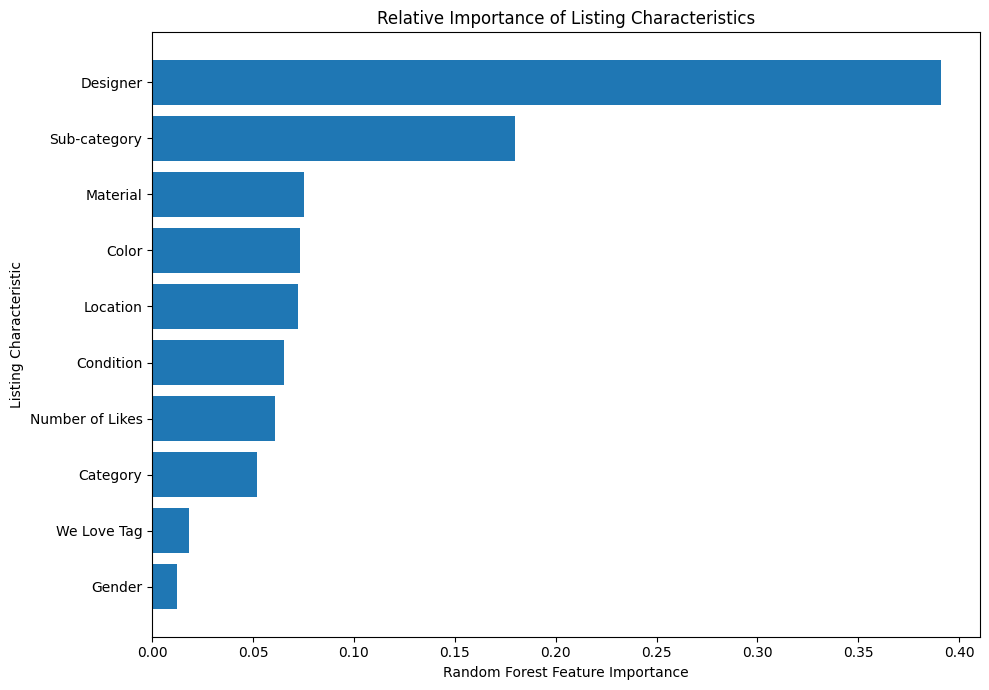

In [23]:
# Prepare grouped feature importance for visualization
grouped_importance_plot = grouped_importance.sort_values(
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    grouped_importance_plot.index,
    grouped_importance_plot.values
)

plt.title("Relative Importance of Listing Characteristics")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Listing Characteristic")

plt.tight_layout()
plt.show()

### Key Finding: What Predicts Luxury Resale Listing Prices?

Designer was the most influential predictor in the Random Forest model, accounting for approximately **39% of total feature importance**. Sub-category was the second most important predictor at approximately **18%**, followed by material, color, seller location, and condition.

These results indicate that **brand identity and product type are particularly important for predicting luxury resale listing prices**. Product attributes such as material and condition also contribute meaningful predictive information, while gender and the platform's "We Love" designation played comparatively smaller roles.

Customer engagement also contributed to the model: number of likes represented approximately **6% of total feature importance**, consistent with the earlier exploratory analysis showing that higher-priced listings tended to receive greater engagement.

Feature importance reflects how much the Random Forest relied on each characteristic when generating predictions. It should not be interpreted as a causal effect or as the percentage of listing price directly explained by each characteristic.

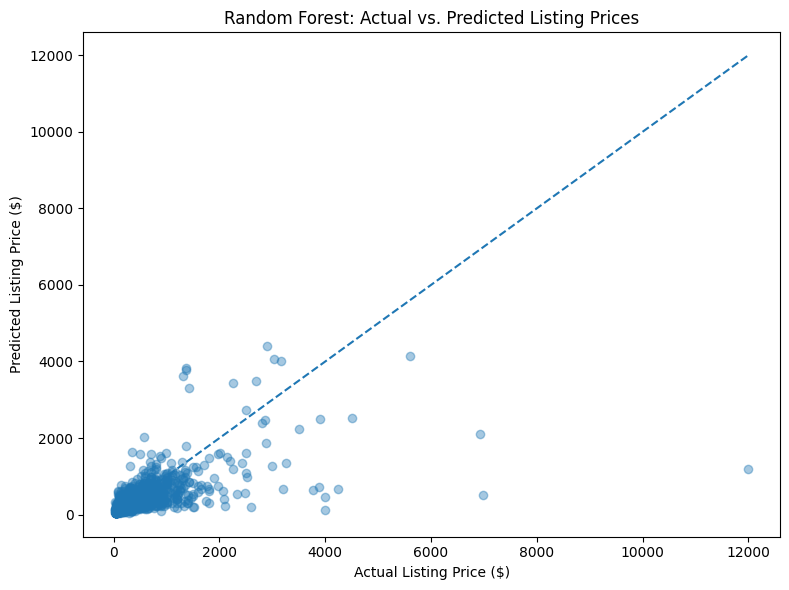

In [28]:
plt.figure(figsize=(8, 6))

# Actual vs. predicted listing prices
plt.scatter(y_test_actual, rf_pred_price, alpha=0.4)

# Perfect-prediction reference line
min_price = min(y_test_actual.min(), rf_pred_price.min())
max_price = max(y_test_actual.max(), rf_pred_price.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Listing Price ($)")
plt.ylabel("Predicted Listing Price ($)")
plt.title("Random Forest: Actual vs. Predicted Listing Prices")

plt.tight_layout()
plt.show()

### Actual vs. Predicted Prices

The Random Forest model captures the general pricing pattern for the majority of listings, particularly within the lower and mid-range price segments. However, prediction errors become substantially larger among the highest-priced luxury items.

Several high-value listings fall well below the perfect-prediction line, indicating that the model tends to **underpredict prices at the extreme upper end of the market**. This suggests that exceptionally expensive luxury items may depend on additional factors not captured in the dataset, such as specific product models, rarity, collection, age, or other item-level characteristics.

Overall, the model provides meaningful predictive information about luxury resale listing prices, but its performance is stronger for typical marketplace listings than for rare, exceptionally high-value items.

## Key Findings & Business Implications

This analysis demonstrates that luxury resale listing prices are shaped by a combination of **brand positioning, product characteristics, and marketplace engagement**.

### Key Findings

**1. Designer is the strongest predictor of listing price.**  
Designer accounted for approximately **39% of the Random Forest model's total feature importance**, substantially more than any other characteristic. This reinforces the importance of brand equity in luxury resale pricing.

**2. Product type also plays an important role in pricing.**  
Sub-category represented approximately **18% of model feature importance**, with handbags emerging as an especially important product segment. Within handbags, substantial price differences were observed across designers, with Chanel and Hermès commanding particularly high median listing prices.

**3. Customer engagement is associated with higher-priced listings.**  
Median listing price increased consistently across engagement groups, from approximately **$190 for listings with no likes to $393 for listings with 26+ likes**. While this relationship is not necessarily causal, engagement may provide useful information about product desirability and marketplace demand.

**4. Condition, material, color, and seller location contribute additional pricing information.**  
Although individually less influential than designer and product type, these characteristics collectively contribute to the model's ability to distinguish between differently priced listings.

**5. Machine learning improves price prediction, but important uncertainty remains.**  
The Random Forest model improved upon the baseline linear regression, achieving an **R² of 0.586**, compared with **0.552** for linear regression. The Random Forest also reduced MAE from approximately **$182 to $175**.

The model performed best across typical marketplace listings but tended to underpredict exceptionally high-priced products, suggesting that additional variables such as specific product model, rarity, collection, age, or other item-level characteristics may be necessary to explain pricing at the highest end of the luxury resale market.

### Business Implications

For luxury resale platforms, these findings suggest that pricing systems should place significant emphasis on **designer and product-level segmentation rather than relying on broad category averages**. Engagement signals may also provide useful supplementary information when evaluating product demand.

From a merchandising perspective, identifying combinations of designer, product type, condition, and marketplace engagement associated with higher listing values could support **pricing recommendations, inventory prioritization, merchandising strategy, and seller guidance**.

Overall, the results demonstrate how marketplace data can be combined with SQL, exploratory analysis, and machine learning to generate actionable insights into luxury resale pricing.